Import Libraries

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Load Dataset

In [2]:
# Load dataset

df = pd.read_csv('/content/Housing.csv')

# Show first rows

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Insights

In [3]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Check outliers and Missing values

In [4]:
# Missing values

df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Data Visualization

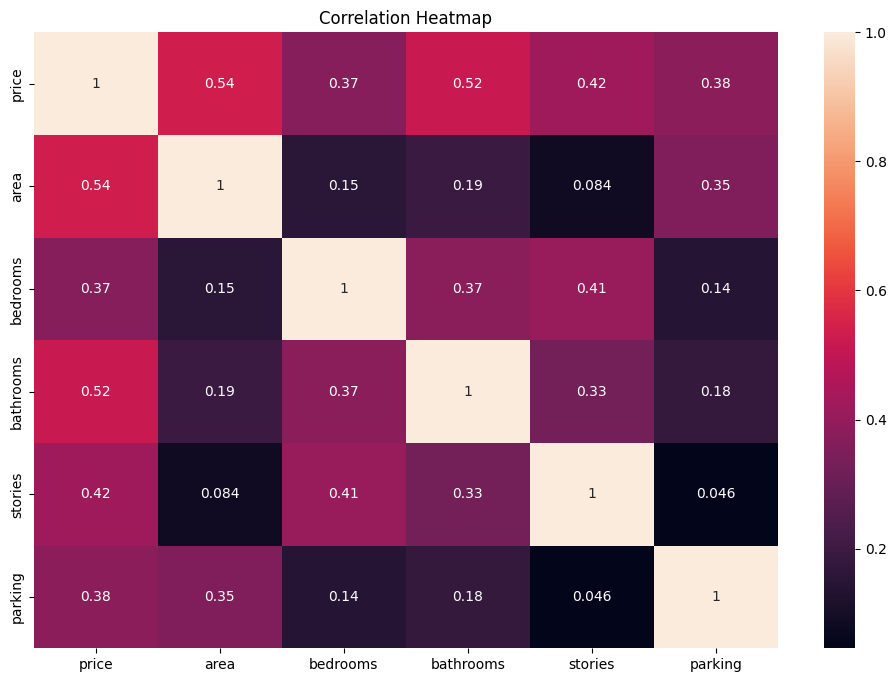

In [5]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

Feature engineering

In [7]:
# Features

X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]

# Target

y = df['price']

Data Splitting

In [8]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 436
Testing Data: 109


Create a Model

In [10]:
# Create model

model = LinearRegression()

Train the model

In [11]:
# Train model

model.fit(X_train, y_train)


LinearRegression()

Make Predictions

In [12]:
# Predictions

predictions = model.predict(X_test)

print(predictions[:5])

[6178627.50326817 6370140.85865473 3283148.1570249  4226007.94816032
 3409685.55116741]


Compare actual outputs and predicted outputs

In [13]:
# Comparison table

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head()

,Actual,Predicted
316,4060000,6.178628e+06
77,6650000,6.370141e+06
360,3710000,3.283148e+06
90,6440000,4.226008e+06
493,2800000,3.409686e+06


Model Evaluation

In [14]:
# Evaluation metrics

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Absolute Error: 1127483.352323519
R2 Score: 0.5464062355495871


Custom prediction(Testing Phase)

In [16]:
# Custom prediction

house = [[5000, 4, 3, 2, 2]]

predicted_price = model.predict(house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 7424039.786788743


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Visualization

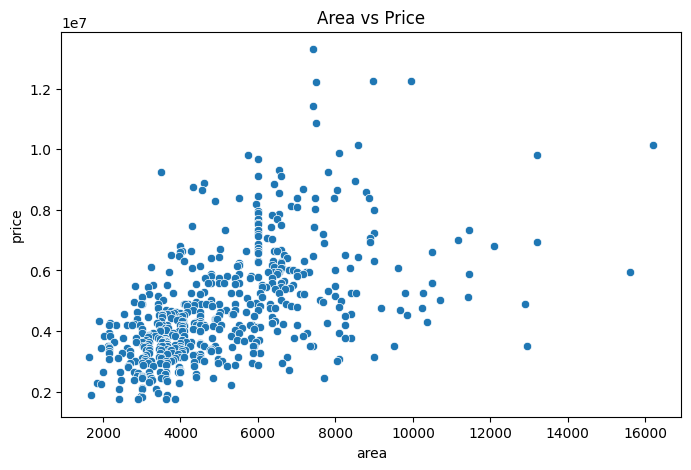

In [17]:
# Area vs Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title("Area vs Price")

plt.show()

Feature Importance

In [18]:
# Feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance

,Feature,Coefficient
0,area,3.088670e+02
1,bedrooms,1.512468e+05
2,bathrooms,1.185732e+06
3,stories,4.951008e+05
4,parking,3.376608e+05
